# SDC — Sistem Rekomendasi Course Sertifikasi & Pelatihan
## Berbasis Model Klasifikasi Machine Learning

**Proyek:** SDC Dashboard – Monitoring & Evaluasi Sertifikasi Tenaga Kerja Pariwisata  
**Scope notebook ini:**
1. Eksplorasi & validasi data dummy (EDA)
2. Preprocessing & feature engineering
3. Training multi-model klasifikasi
4. Evaluasi & perbandingan model
5. Analisis feature importance
6. Inference — prediksi rekomendasi untuk pegawai baru

---
**Alur sistem:**
```
Profil skill pegawai  →  Model Klasifikasi  →  Label Kategori Course  →  Lookup data_course.csv  →  Daftar course
```


## 0. Setup & Import Library

In [21]:
# Install dependencies jika belum ada
# !pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q


In [22]:
import warnings
warnings.filterwarnings("ignore")

# Core
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing & pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Model klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluasi
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    roc_auc_score, roc_curve, auc
)

# Imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("Library berhasil diimport.")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")


Library berhasil diimport.
Scikit-learn version: 1.9.0


---
## 1. Load & Eksplorasi Data (EDA)

Dua dataset yang digunakan:
- `data_pegawai.csv` — 400 baris, fitur skill pegawai + label ground truth
- `data_course.csv`  — 24 baris, katalog course + metadata kategori (lookup table)


In [23]:
# ── Load data
df_pegawai = pd.read_csv("data_pegawai.csv")
df_course  = pd.read_csv("data_course.csv")

print(f"Data Pegawai : {df_pegawai.shape[0]} baris × {df_pegawai.shape[1]} kolom")
print(f"Data Course  : {df_course.shape[0]} baris × {df_course.shape[1]} kolom")

Data Pegawai : 400 baris × 25 kolom
Data Course  : 24 baris × 18 kolom


In [24]:
# ── Gambaran umum data pegawai
print("=== 5 baris pertama ===")
df_pegawai.head()


=== 5 baris pertama ===


,id_pegawai,nama_pegawai,jabatan,divisi,status_sertifikat,pre_score,post_score,kinerja_q1_2024,kinerja_q2_2024,kinerja_q3_2024,...,skill_penguasaan_teknis,skill_kepatuhan_sop,skill_kepemimpinan,skill_bahasa_asing,skill_problem_solving,skill_digital_literacy,label_rekomendasi,label_rekomendasi_nama,label_tindakan,label_tindakan_nama
0,EMP0001,Budi Wijaya Kurniawan,Front Desk Officer,Akomodasi,Aktif,45,76,2.89,3.00,2.95,...,3.61,4.12,1.73,3.00,3.27,3.00,3,Sertifikasi Lanjutan & Pengembangan Karir,1,Pengawasan & Evaluasi Ketat
1,EMP0002,Nabila Nugraha Maulana,Front Desk Officer,Akomodasi,Aktif,46,67,2.96,2.96,2.97,...,3.00,4.00,2.43,4.07,3.12,3.00,1,Teknis & Kepatuhan SOP,2,Pertahankan & Stabilkan
2,EMP0003,Budi Kusuma Prasetyo,Front Desk Officer,Akomodasi,Aktif,50,79,2.97,2.99,3.09,...,3.82,3.54,2.34,3.00,4.00,3.91,3,Sertifikasi Lanjutan & Pengembangan Karir,2,Pertahankan & Stabilkan
3,EMP0004,Farah Wibowo Maulana,Front Desk Officer,Akomodasi,Aktif,43,74,2.63,2.83,2.90,...,2.40,3.42,3.00,3.05,3.05,5.00,1,Teknis & Kepatuhan SOP,3,Percepatan Karir
4,EMP0005,Fajar Nugraha Anggraini,Front Desk Officer,Akomodasi,Belum,45,65,3.00,2.84,2.70,...,4.00,3.49,2.10,3.00,3.00,3.77,3,Sertifikasi Lanjutan & Pengembangan Karir,1,Pengawasan & Evaluasi Ketat


In [25]:
# ── Tipe data & missing values
print("Info kolom:")
df_pegawai.info()
print(f"\nTotal missing values: {df_pegawai.isnull().sum().sum()}")


Info kolom:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_pegawai               400 non-null    str    
 1   nama_pegawai             400 non-null    str    
 2   jabatan                  400 non-null    str    
 3   divisi                   400 non-null    str    
 4   status_sertifikat        400 non-null    str    
 5   pre_score                400 non-null    int64  
 6   post_score               400 non-null    int64  
 7   kinerja_q1_2024          400 non-null    float64
 8   kinerja_q2_2024          400 non-null    float64
 9   kinerja_q3_2024          400 non-null    float64
 10  kinerja_q4_2024          400 non-null    float64
 11  kinerja_q1_2025          400 non-null    float64
 12  kinerja_q2_2025          400 non-null    float64
 13  skill_komunikasi         400 non-null    float64
 14  skill_layanan_tamu       

In [26]:
# ── Statistik deskriptif skill
skill_cols = [c for c in df_pegawai.columns if c.startswith("skill_")]
print("Statistik 8 dimensi skill (skala 1.0 – 5.0):")
df_pegawai[skill_cols].describe().round(3)


Statistik 8 dimensi skill (skala 1.0 – 5.0):


,skill_komunikasi,skill_layanan_tamu,skill_penguasaan_teknis,skill_kepatuhan_sop,skill_kepemimpinan,skill_bahasa_asing,skill_problem_solving,skill_digital_literacy
count,400.000,400.000,400.000,400.000,400.000,400.000,400.000,400.000
mean,3.449,3.688,3.588,3.803,2.841,3.013,3.202,3.052
std,0.712,0.667,0.728,0.625,0.901,0.856,0.751,0.836
min,1.160,1.780,1.880,2.000,1.000,1.000,1.290,1.000
25%,3.000,3.070,3.000,3.340,2.027,2.420,2.798,2.428
50%,3.410,3.810,3.665,3.940,2.950,3.000,3.035,3.000
75%,4.000,4.000,4.000,4.110,3.378,3.592,3.872,3.802
max,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000


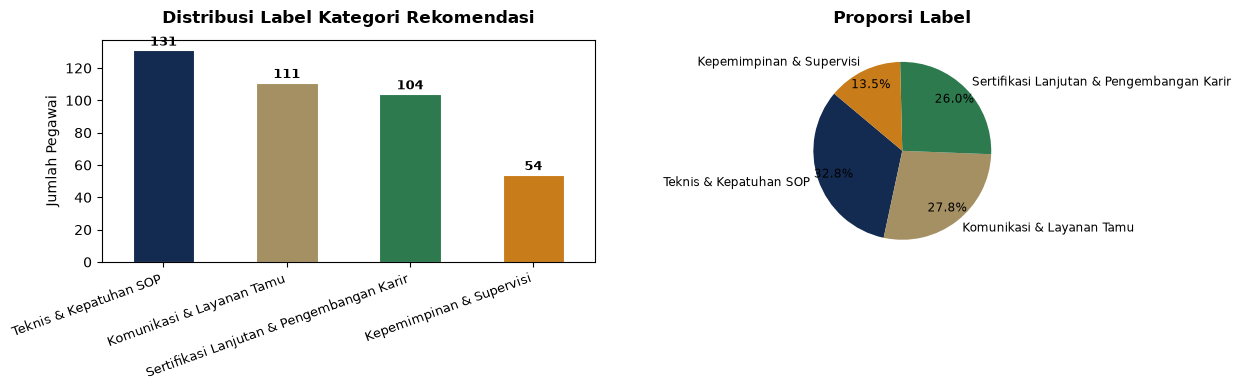


Class balance:
  Teknis & Kepatuhan SOP                        : 131 (32.8%)
  Komunikasi & Layanan Tamu                     : 111 (27.8%)
  Sertifikasi Lanjutan & Pengembangan Karir     : 104 (26.0%)
  Kepemimpinan & Supervisi                      : 54 (13.5%)


In [27]:
# ── Distribusi label target
label_counts = df_pegawai["label_rekomendasi_nama"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ["#132B50", "#A49063", "#2d7a4f", "#c97c1a"]
label_counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Distribusi Label Kategori Rekomendasi", fontweight="bold", pad=12)
axes[0].set_xlabel("")
axes[0].set_xticklabels(label_counts.index, rotation=20, ha="right", fontsize=9)
axes[0].set_ylabel("Jumlah Pegawai")
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=colors, autopct="%1.1f%%", startangle=140,
            textprops={"fontsize": 8.5}, pctdistance=0.82)
axes[1].set_title("Proporsi Label", fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("plot_label_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nClass balance:")
for name, cnt in label_counts.items():
    print(f"  {name:<45} : {cnt} ({cnt/len(df_pegawai)*100:.1f}%)")


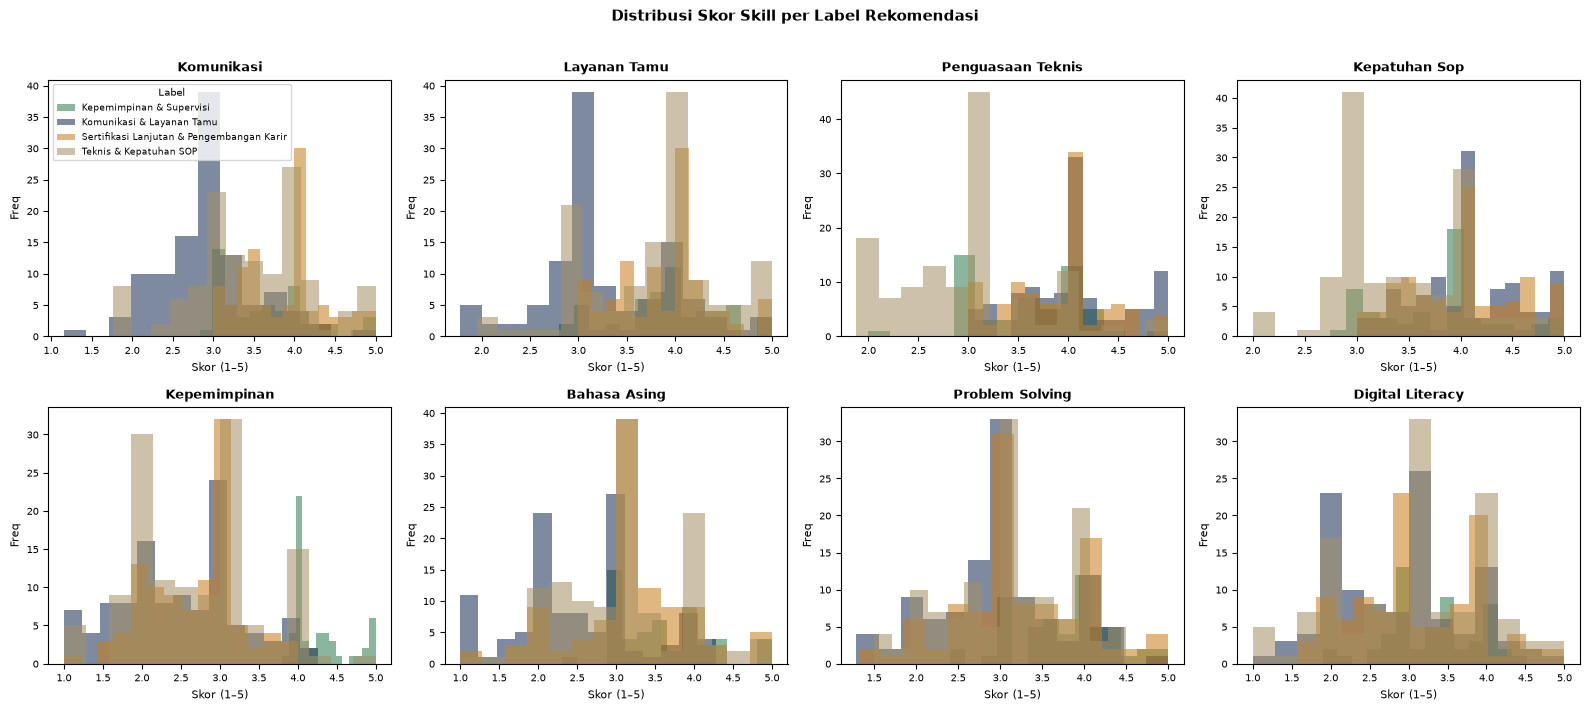

In [28]:
# ── Distribusi skill per label
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = {"Komunikasi & Layanan Tamu": "#132B50",
           "Teknis & Kepatuhan SOP": "#A49063",
           "Kepemimpinan & Supervisi": "#2d7a4f",
           "Sertifikasi Lanjutan & Pengembangan Karir": "#c97c1a"}

for i, skill in enumerate(skill_cols):
    label_name = skill.replace("skill_", "").replace("_", " ").title()
    for label, grp in df_pegawai.groupby("label_rekomendasi_nama"):
        axes[i].hist(grp[skill], bins=14, alpha=0.55,
                     color=palette[label], label=label, edgecolor="none")
    axes[i].set_title(label_name, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Skor (1–5)", fontsize=8)
    axes[i].set_ylabel("Freq", fontsize=8)
    axes[i].tick_params(labelsize=7.5)

axes[0].legend(fontsize=6.5, loc="upper left",
               title="Label", title_fontsize=7)
plt.suptitle("Distribusi Skor Skill per Label Rekomendasi", fontweight="bold", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("plot_skill_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


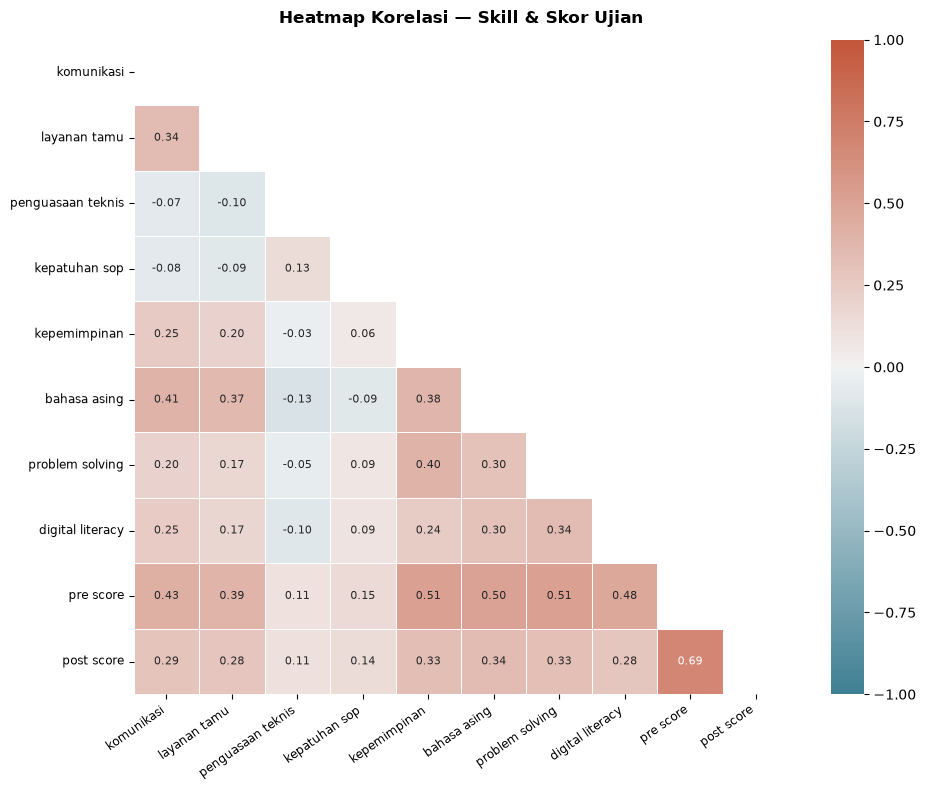

In [29]:
# ── Heatmap korelasi antar skill
corr = df_pegawai[skill_cols + ["pre_score", "post_score"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, annot_kws={"size": 8}, ax=ax)
ax.set_xticklabels([c.replace("skill_","").replace("_"," ") for c in corr.columns],
                   rotation=35, ha="right", fontsize=8.5)
ax.set_yticklabels([c.replace("skill_","").replace("_"," ") for c in corr.index],
                   rotation=0, fontsize=8.5)
ax.set_title("Heatmap Korelasi — Skill & Skor Ujian", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


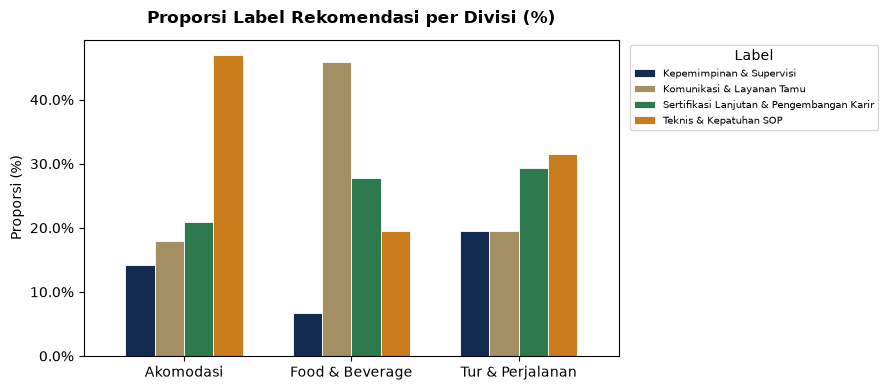

In [30]:
# ── Distribusi label per divisi
cross = pd.crosstab(df_pegawai["divisi"], df_pegawai["label_rekomendasi_nama"],
                    normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 4))
cross.plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.6, width=0.7)
ax.set_title("Proporsi Label Rekomendasi per Divisi (%)", fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Proporsi (%)")
ax.set_xticklabels(cross.index, rotation=0, fontsize=10)
ax.legend(fontsize=7.5, bbox_to_anchor=(1.01, 1), loc="upper left", title="Label")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig("plot_label_per_divisi.png", dpi=120, bbox_inches="tight")
plt.show()


In [31]:
# ── Gambaran data course
print("=== Katalog Course ===")
df_course[["id_course","nama_course","provider","level","durasi","label_kategori_nama"]].to_string(index=False)


=== Katalog Course ===


'id_course                                  nama_course                               provider             level   durasi                       label_kategori_nama\n   CRS001         Hospitality Communication Excellence               LPK Pariwisata Indonesia             Dasar 3 minggu                 Komunikasi & Layanan Tamu\n   CRS002        Guest Service & Experience Management                 ASEAN Tourism Training          Menengah 6 minggu                 Komunikasi & Layanan Tamu\n   CRS003     Cross-Cultural Communication for Tourism           LPK Pariwisata Internasional          Menengah 4 minggu                 Komunikasi & Layanan Tamu\n   CRS004     Hospitality English — Intermediate Level                      BNSP / LPK Bahasa          Menengah  2 bulan                 Komunikasi & Layanan Tamu\n   CRS005        Complaint Handling & Service Recovery Perhimpunan Hotel & Restoran Indonesia          Menengah 2 minggu                 Komunikasi & Layanan Tamu\n   CRS006      

---
## 2. Preprocessing & Feature Engineering

**Fitur yang digunakan:**
- 8 dimensi skill (numerik, skala 1–5) — fitur utama
- `pre_score`, `post_score` — skor ujian (numerik)
- `kinerja_q*` — skor kinerja 6 kuartal (numerik)  
- `divisi`, `status_sertifikat` — fitur kategorikal

**Feature engineering tambahan:**
- `delta_score` = post_score − pre_score
- `avg_kinerja_pre` = rata-rata kinerja Q1–Q3 2024
- `avg_kinerja_post` = rata-rata kinerja Q4 2024–Q2 2025
- `delta_kinerja` = avg_kinerja_post − avg_kinerja_pre
- `avg_skill` = rata-rata 8 dimensi skill


In [32]:
# ── Feature engineering
df = df_pegawai.copy()

df["delta_score"]       = df["post_score"] - df["pre_score"]
df["avg_kinerja_pre"]   = df[["kinerja_q1_2024","kinerja_q2_2024","kinerja_q3_2024"]].mean(axis=1).round(3)
df["avg_kinerja_post"]  = df[["kinerja_q4_2024","kinerja_q1_2025","kinerja_q2_2025"]].mean(axis=1).round(3)
df["delta_kinerja"]     = (df["avg_kinerja_post"] - df["avg_kinerja_pre"]).round(3)
df["avg_skill"]         = df[skill_cols].mean(axis=1).round(3)

print("Feature engineering selesai. Kolom baru:")
new_feats = ["delta_score","avg_kinerja_pre","avg_kinerja_post","delta_kinerja","avg_skill"]
print(df[new_feats].describe().round(3).to_string())


Feature engineering selesai. Kolom baru:
       delta_score  avg_kinerja_pre  avg_kinerja_post  delta_kinerja  avg_skill
count      400.000          400.000           400.000        400.000    400.000
mean        22.055            2.826             2.828          0.002      3.329
std          7.024            0.346             0.343          0.180      0.388
min          9.000            1.940             1.857         -0.510      2.189
25%         16.000            2.650             2.627         -0.110      3.057
50%         22.000            2.938             2.923         -0.003      3.380
75%         28.000            3.053             3.047          0.097      3.612
max         35.000            3.490             3.523          0.580      4.269


In [33]:
# ── Definisi fitur & target
NUMERIC_FEATURES = skill_cols + [
    "pre_score", "post_score", "delta_score",
    "avg_kinerja_pre", "avg_kinerja_post", "delta_kinerja",
    "avg_skill"
]
CATEGORICAL_FEATURES = ["divisi", "status_sertifikat"]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "label_rekomendasi"

print(f"Total fitur     : {len(ALL_FEATURES)}")
print(f"  - Numerik     : {len(NUMERIC_FEATURES)}")
print(f"  - Kategorikal : {len(CATEGORICAL_FEATURES)}")
print(f"Target          : {TARGET} (4 kelas)")


Total fitur     : 17
  - Numerik     : 15
  - Kategorikal : 2
Target          : label_rekomendasi (4 kelas)


In [34]:
# ── Train-test split (stratified 80/20)
X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train set : {X_train.shape[0]} sampel")
print(f"Test set  : {X_test.shape[0]} sampel")
print(f"\nDistribusi label di train set:")
print(y_train.value_counts().sort_index())
print(f"\nDistribusi label di test set:")
print(y_test.value_counts().sort_index())


Train set : 320 sampel
Test set  : 80 sampel

Distribusi label di train set:
label_rekomendasi
0     89
1    105
2     43
3     83
Name: count, dtype: int64

Distribusi label di test set:
label_rekomendasi
0    22
1    26
2    11
3    21
Name: count, dtype: int64


In [35]:
# ── Preprocessing pipeline
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,  NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Shape setelah preprocessing:")
print(f"  X_train : {X_train_proc.shape}")
print(f"  X_test  : {X_test_proc.shape}")


Shape setelah preprocessing:
  X_train : (320, 21)
  X_test  : (80, 21)


In [36]:
# ── Cek class imbalance — pertimbangan SMOTE
from collections import Counter

print("Distribusi kelas sebelum SMOTE:", Counter(y_train))

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(
    X_train_proc,
    y_train
)

print("Distribusi kelas sesudah SMOTE :", Counter(y_train_sm))

label_names_map = (
    df_pegawai[
        [
            "label_rekomendasi",
            "label_rekomendasi_nama"
        ]
    ]
    .drop_duplicates()
    .set_index("label_rekomendasi")
    ["label_rekomendasi_nama"]
    .to_dict()
)

print("\nKeterangan label:")
for k, v in sorted(label_names_map.items()):
    print(f"  {k} = {v}")

Distribusi kelas sebelum SMOTE: Counter({1: 105, 0: 89, 3: 83, 2: 43})
Distribusi kelas sesudah SMOTE : Counter({3: 105, 1: 105, 2: 105, 0: 105})

Keterangan label:
  0 = Komunikasi & Layanan Tamu
  1 = Teknis & Kepatuhan SOP
  2 = Kepemimpinan & Supervisi
  3 = Sertifikasi Lanjutan & Pengembangan Karir


---
## 3. Training Multi-Model Klasifikasi

Model yang akan dibandingkan:

| # | Model | Keterangan |
|---|-------|-----------|
| 1 | Logistic Regression | Baseline linear |
| 2 | Decision Tree | Interpretable, prone to overfit |
| 3 | Random Forest | Ensemble bagging |
| 4 | Gradient Boosting | Ensemble boosting |
| 5 | Extra Trees | Randomized ensemble |
| 6 | SVM (RBF kernel) | Margin-based, nonlinear |
| 7 | K-Nearest Neighbors | Instance-based |
| 8 | Naive Bayes | Probabilistic baseline |

Semua model dilatih dengan **data setelah SMOTE** (`X_train_sm`, `y_train_sm`)  
dan dievaluasi pada **test set asli** (tanpa SMOTE).


In [37]:
# ── Definisi semua model
MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=SEED, C=1.0
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=5, random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        random_state=SEED
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", C=1.0, gamma="scale",
        probability=True, random_state=SEED
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7, weights="distance", n_jobs=-1
    ),
    "Naive Bayes": GaussianNB(),
}

print(f"{len(MODELS)} model siap dilatih.")


8 model siap dilatih.


In [38]:
# ── Training & evaluasi semua model
from sklearn.model_selection import cross_val_score

results = {}

print(f"{'Model':<25} {'CV Accuracy':>12} {'Test Accuracy':>14} {'Test F1-macro':>14}")
print("-" * 68)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

for name, model in MODELS.items():
    cv_pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf",   model)
    ])
    cv_scores = cross_val_score(
        cv_pipeline, X_train_proc, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_pipeline.fit(
        X_train_proc,
        y_train
    )

    y_pred = cv_pipeline.predict(
        X_test_proc
    )
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average="macro")

    results[name] = {
        "model": cv_pipeline,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "test_acc": test_acc,
        "test_f1": test_f1,
        "y_pred": y_pred,
    }

    print(f"{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.3f}   "
          f"{test_acc:.4f}         {test_f1:.4f}")

print("\nTraining selesai.")


Model                      CV Accuracy  Test Accuracy  Test F1-macro
--------------------------------------------------------------------
Logistic Regression       0.7176 ± 0.026   0.7500         0.7527
Decision Tree             0.7654 ± 0.061   0.7625         0.7666
Random Forest             0.8204 ± 0.024   0.7750         0.7800
Gradient Boosting         0.8004 ± 0.039   0.8625         0.8613
Extra Trees               0.7309 ± 0.026   0.6625         0.6772
SVM (RBF)                 0.7513 ± 0.043   0.7125         0.7169
KNN                       0.6600 ± 0.056   0.5500         0.5405
Naive Bayes               0.6567 ± 0.082   0.6000         0.6058

Training selesai.


---
## 4. Evaluasi & Perbandingan Model


In [39]:
# ── Ringkasan performa semua model
df_results = pd.DataFrame([
    {
        "Model":                name,
        "CV F1-macro (mean)":   r["cv_mean"],
        "CV F1-macro (std)":    r["cv_std"],
        "Test Accuracy":        r["test_acc"],
        "Test F1-macro":        r["test_f1"],
        "CV-Test Gap":          round(r["cv_mean"] - r["test_f1"], 4),
        "Suspect Overfit":      "YA" if r["test_f1"] >= 0.999 else
                                "Gap Besar" if abs(r["cv_mean"] - r["test_f1"]) > 0.15 else "OK",
    }
    for name, r in results.items()
]).sort_values("Test F1-macro", ascending=False).reset_index(drop=True)
df_results.index += 1

df_valid = df_results[
    (df_results["Test F1-macro"] < 0.999) &
    (df_results["CV-Test Gap"].abs() < 0.15)
]
best_name_safe = df_valid.iloc[0]["Model"] if len(df_valid) > 0 else df_results.iloc[0]["Model"]

print("=== Perbandingan Model (diurutkan Test F1-macro) ===")
print(df_results.to_string())
excluded = df_results[df_results["Suspect Overfit"] == "YA"]["Model"].tolist()
excluded_str = ", ".join(excluded) if excluded else "tidak ada"
print(f"\n Model yang dikecualikan karena suspect overfit: {excluded_str}")
print(f"    karena skor sempurna di data dummy mengindikasikan overfitting.")
print(f"\n  Model terbaik yang valid untuk produksi: {best_name_safe}")


=== Perbandingan Model (diurutkan Test F1-macro) ===
                 Model  CV F1-macro (mean)  CV F1-macro (std)  Test Accuracy  Test F1-macro  CV-Test Gap Suspect Overfit
1    Gradient Boosting            0.800376           0.039152         0.8625       0.861310      -0.0609              OK
2        Random Forest            0.820408           0.024125         0.7750       0.780021       0.0404              OK
3        Decision Tree            0.765431           0.060699         0.7625       0.766612      -0.0012              OK
4  Logistic Regression            0.717605           0.025977         0.7500       0.752713      -0.0351              OK
5            SVM (RBF)            0.751332           0.043184         0.7125       0.716934       0.0344              OK
6          Extra Trees            0.730936           0.025602         0.6625       0.677180       0.0538              OK
7          Naive Bayes            0.656694           0.082397         0.6000       0.605811       0.

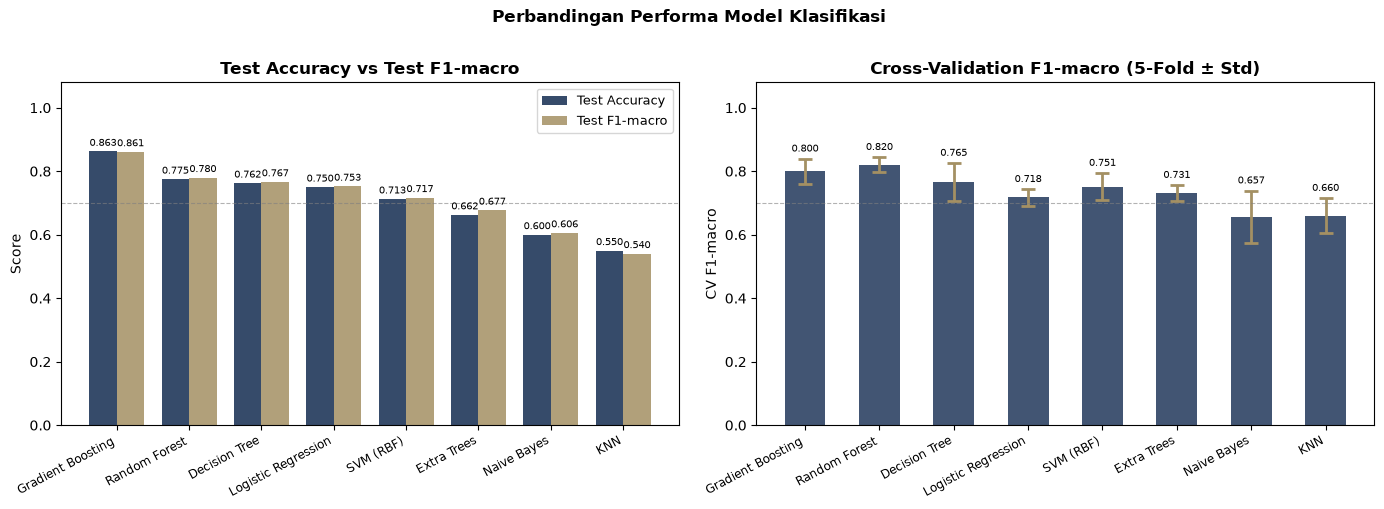

In [40]:
# ── Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = df_results["Model"].tolist()
test_acc    = df_results["Test Accuracy"].tolist()
test_f1     = df_results["Test F1-macro"].tolist()
cv_mean     = df_results["CV F1-macro (mean)"].tolist()
cv_std      = df_results["CV F1-macro (std)"].tolist()

x = np.arange(len(model_names))
w = 0.38
bars1 = axes[0].bar(x - w/2, test_acc, w, label="Test Accuracy", color="#132B50", alpha=0.85)
bars2 = axes[0].bar(x + w/2, test_f1,  w, label="Test F1-macro", color="#A49063", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=28, ha="right", fontsize=8.5)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.08)
axes[0].set_title("Test Accuracy vs Test F1-macro", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

axes[1].bar(x, cv_mean, 0.55, color="#132B50", alpha=0.8, label="CV Mean F1-macro")
axes[1].errorbar(x, cv_mean, yerr=cv_std, fmt="none", color="#A49063",
                 capsize=5, linewidth=2, capthick=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=28, ha="right", fontsize=8.5)
axes[1].set_ylabel("CV F1-macro")
axes[1].set_ylim(0, 1.08)
axes[1].set_title("Cross-Validation F1-macro (5-Fold ± Std)", fontweight="bold")
axes[1].axhline(0.7, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
for i, (m, s) in enumerate(zip(cv_mean, cv_std)):
    axes[1].text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Perbandingan Performa Model Klasifikasi", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


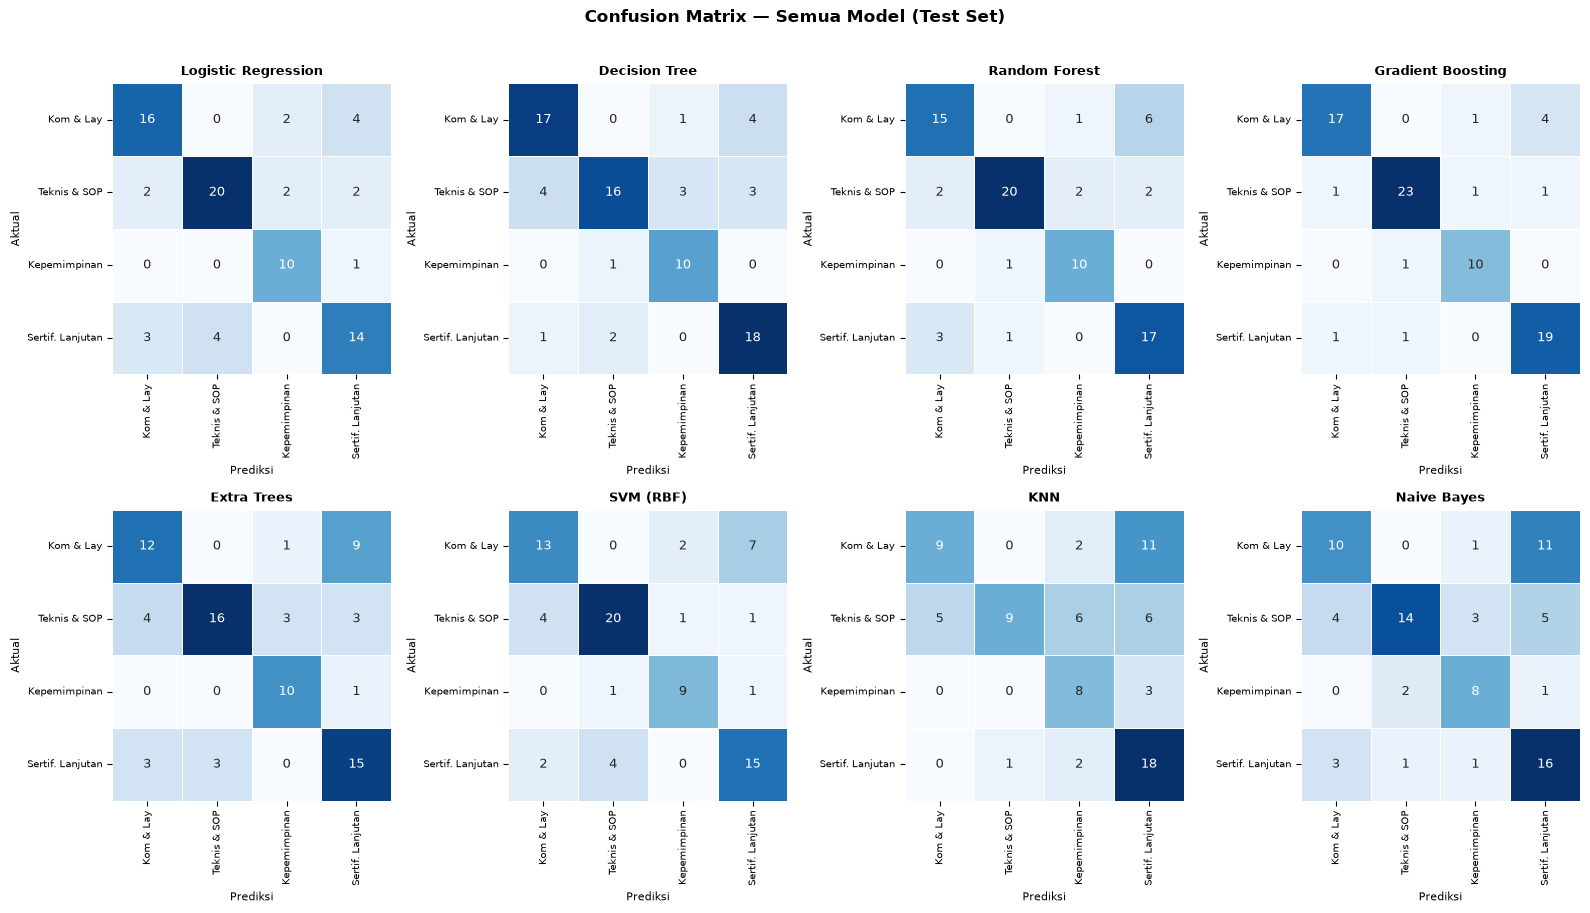

In [41]:
# ── Confusion matrix semua model
label_short = ["Kom & Lay", "Teknis & SOP", "Kepemimpinan", "Sertif. Lanjutan"]

n_models = len(MODELS)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4 + 1))
axes = axes.flatten()

for idx, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_short, yticklabels=label_short,
                ax=axes[idx], linewidths=0.5, cbar=False,
                annot_kws={"size": 9})
    axes[idx].set_title(name, fontsize=9, fontweight="bold", pad=6)
    axes[idx].set_xlabel("Prediksi", fontsize=8)
    axes[idx].set_ylabel("Aktual", fontsize=8)
    axes[idx].tick_params(labelsize=7.5)

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Confusion Matrix — Semua Model (Test Set)", fontweight="bold", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("plot_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


In [42]:
# ── Classification report model terbaik
label_names_list = [
    "Komunikasi & Layanan Tamu",
    "Teknis & Kepatuhan SOP",
    "Kepemimpinan & Supervisi",
    "Sertifikasi Lanjutan & Pengembangan Karir"
]

best_name = best_name_safe
best_res  = results[best_name]

print(f"=== Classification Report: {best_name} ===")
print(f"(Dipilih karena F1 realistis dan CV-Test gap wajar)")
print(f"Test Accuracy : {best_res['test_acc']:.4f}")
print(f"Test F1-macro : {best_res['test_f1']:.4f}")
print()
print(classification_report(
    y_test, best_res["y_pred"],
    target_names=label_names_list
))

=== Classification Report: Gradient Boosting ===
(Dipilih karena F1 realistis dan CV-Test gap wajar)
Test Accuracy : 0.8625
Test F1-macro : 0.8613

                                           precision    recall  f1-score   support

                Komunikasi & Layanan Tamu       0.89      0.77      0.83        22
                   Teknis & Kepatuhan SOP       0.92      0.88      0.90        26
                 Kepemimpinan & Supervisi       0.83      0.91      0.87        11
Sertifikasi Lanjutan & Pengembangan Karir       0.79      0.90      0.84        21

                                 accuracy                           0.86        80
                                macro avg       0.86      0.87      0.86        80
                             weighted avg       0.87      0.86      0.86        80



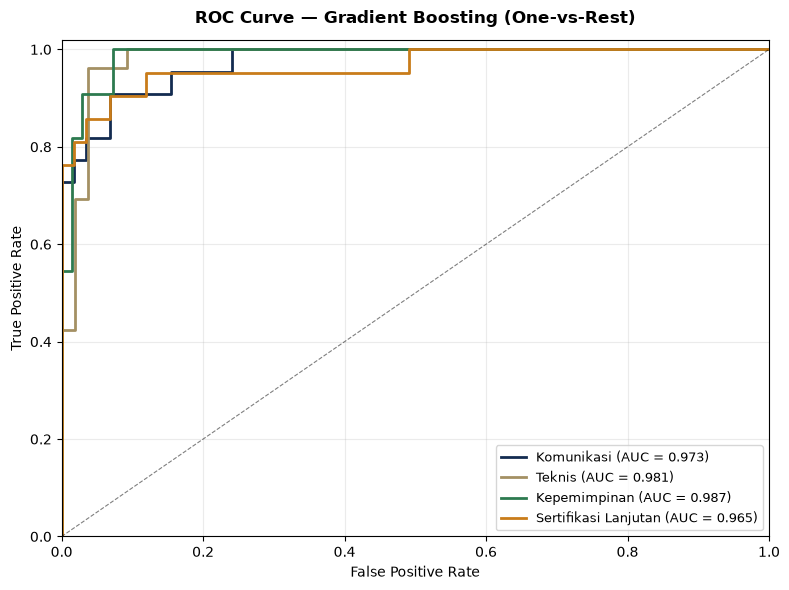


Macro-average AUC (Gradient Boosting): 0.9767


In [43]:
# ── ROC-AUC Curve (One-vs-Rest) — model terbaik
best_model = best_res["model"]
n_classes  = 4
colors_roc = ["#132B50", "#A49063", "#2d7a4f", "#c97c1a"]

y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_score    = best_model.predict_proba(X_test_proc)

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_val = auc(fpr, tpr)
    short = label_names_list[i].split("&")[0].strip()
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
            label=f"{short} (AUC = {roc_auc_val:.3f})")

ax.plot([0,1],[0,1], "k--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate", fontsize=10)
ax.set_title(f"ROC Curve — {best_name} (One-vs-Rest)", fontweight="bold", pad=12)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("plot_roc_curve.png", dpi=120, bbox_inches="tight")
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print(f"\nMacro-average AUC ({best_name}): {macro_auc:.4f}")


---
## 5. Analisis Feature Importance

Menggunakan model terbaik untuk mengidentifikasi fitur mana yang paling berpengaruh dalam prediksi.


In [44]:
# ── Ambil nama fitur setelah preprocessing
ohe_feature_names = preprocessor.named_transformers_["cat"]["ohe"] \
                    .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_feature_names = NUMERIC_FEATURES + ohe_feature_names

print(f"Total fitur setelah encoding: {len(all_feature_names)}")
print("\nFitur kategorikal setelah OHE:")
print(ohe_feature_names)


Total fitur setelah encoding: 21

Fitur kategorikal setelah OHE:
['divisi_Akomodasi', 'divisi_Food & Beverage', 'divisi_Tur & Perjalanan', 'status_sertifikat_Aktif', 'status_sertifikat_Belum', 'status_sertifikat_Kadaluarsa']


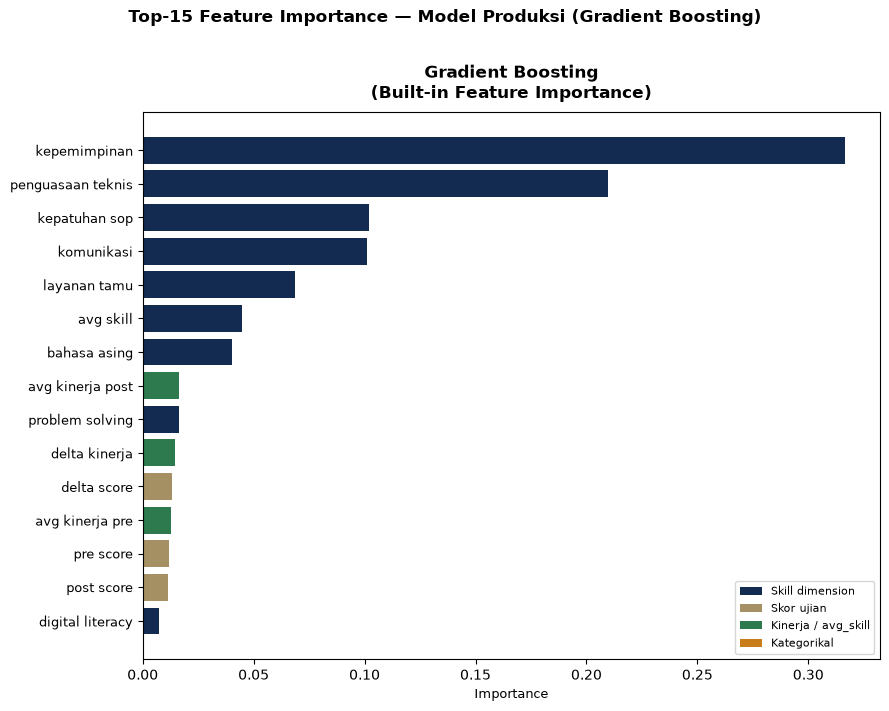

In [45]:
from sklearn.inspection import permutation_importance

top_n       = 15
best_model  = results[best_name_safe]["model"]
clf_step    = best_model.named_steps["clf"]
has_builtin = hasattr(clf_step, "feature_importances_")

# ── Built-in importance (tree-based)
if has_builtin:
    imp_vals   = clf_step.feature_importances_
    imp_source = "Built-in Feature Importance"
else:
    # ── Permutation importance (universal — SVM, LR, dll)
    perm = permutation_importance(
        best_model, X_test_proc, y_test,
        n_repeats=30, random_state=SEED, scoring="f1_macro"
    )
    imp_vals   = perm.importances_mean
    imp_source = "Permutation Importance (test set)"

min_len    = min(len(imp_vals), len(all_feature_names))
feat_names = all_feature_names[:min_len]
imp_vals   = imp_vals[:min_len]

idx_sorted = np.argsort(imp_vals)[::-1][:top_n]
top_names  = [feat_names[i].replace("skill_","").replace("_"," ")
                            .replace("divisi_","div:")
                            .replace("status_sertifikat_","sert:")
              for i in idx_sorted]
top_vals   = imp_vals[idx_sorted]

bar_c = ["#132B50" if "skill" in feat_names[i] else
         "#A49063" if feat_names[i] in ["pre_score","post_score","delta_score"] else
         "#2d7a4f" if "kinerja" in feat_names[i] or "avg_skill" in feat_names[i] else
         "#c97c1a" for i in idx_sorted]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(len(top_vals)), top_vals[::-1], color=bar_c[::-1], edgecolor="none")
ax.set_yticks(range(len(top_vals)))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_title(f"{best_name_safe}\n({imp_source})", fontweight="bold", pad=10)
ax.set_xlabel("Importance", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#132B50", label="Skill dimension"),
    Patch(facecolor="#A49063", label="Skor ujian"),
    Patch(facecolor="#2d7a4f", label="Kinerja / avg_skill"),
    Patch(facecolor="#c97c1a", label="Kategorikal"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.suptitle(f"Top-{top_n} Feature Importance — Model Produksi ({best_name_safe})",
             fontweight="bold", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

In [46]:
# ── Ringkasan importance rata-rata 3 model
importance_df = pd.DataFrame({
    "Feature":    [feat_names[i] for i in idx_sorted],
    "Importance": top_vals,
    "Source":     imp_source,
}).set_index("Feature")

importance_df.index = [i.replace("skill_","skill:").replace("_"," ")
                        for i in importance_df.index]

print(f"=== Top {top_n} Fitur — {best_name_safe} ({imp_source}) ===")
print(importance_df["Importance"].round(4).to_string())

=== Top 15 Fitur — Gradient Boosting (Built-in Feature Importance) ===
skill:kepemimpinan         0.3165
skill:penguasaan teknis    0.2099
skill:kepatuhan sop        0.1021
skill:komunikasi           0.1012
skill:layanan tamu         0.0685
avg skill                  0.0449
skill:bahasa asing         0.0403
avg kinerja post           0.0165
skill:problem solving      0.0162
delta kinerja              0.0146
delta score                0.0131
avg kinerja pre            0.0127
pre score                  0.0120
post score                 0.0114
skill:digital literacy     0.0074


---
## 6. Hyperparameter Tuning — Model Terbaik

Gunakan GridSearchCV pada model dengan performa tertinggi.


In [47]:
# ── GridSearch pada model terbaik valid (best_name_safe dari Cell 24)

print(f"Menjalankan GridSearchCV untuk: {best_name_safe}")

param_grids = {
    "Random Forest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 5],
        "clf__max_features": ["sqrt", "log2"],
    },

    "Gradient Boosting": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1, 0.2],
        "clf__max_depth": [3, 5, 7],
    },

    "Decision Tree": {
        "clf__max_depth": [5, 10, 15, None],
        "clf__min_samples_leaf": [1, 3, 5],
        "clf__criterion": ["gini", "entropy"],
    },

    "SVM (RBF)": {
        "clf__C": [0.1, 1.0, 10.0],
        "clf__gamma": ["scale", "auto"],
    },
}

base_model_map = {
    "Random Forest":
        RandomForestClassifier(
            random_state=SEED,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=SEED
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=SEED
        ),

    "SVM (RBF)":
        SVC(
            kernel="rbf",
            probability=True,
            random_state=SEED
        ),
}

if best_name_safe in param_grids:

    pipeline = ImbPipeline([
        ("smote", SMOTE(random_state=SEED)),
        ("clf", base_model_map[best_name_safe])
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grids[best_name_safe],
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=SEED
        ),
        scoring="f1_macro",
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(
        X_train_proc,
        y_train
    )

    best_tuned_model = grid_search.best_estimator_

    y_pred_best_tuned = best_tuned_model.predict(
        X_test_proc
    )

    tuned_f1 = f1_score(
        y_test,
        y_pred_best_tuned,
        average="macro"
    )

    print(f"Best params : {grid_search.best_params_}")
    print(f"Best CV F1  : {grid_search.best_score_:.4f}")

    print(
        f"Test Accuracy (tuned {best_name_safe}) : "
        f"{accuracy_score(y_test, y_pred_best_tuned):.4f}"
    )

    print(
        f"Test F1-macro (tuned {best_name_safe}) : "
        f"{tuned_f1:.4f}"
    )
else:
    best_tuned_model  = results[best_name_safe]["model"]
    y_pred_best_tuned = results[best_name_safe]["y_pred"]

Menjalankan GridSearchCV untuk: Gradient Boosting
Best params : {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Best CV F1  : 0.8147
Test Accuracy (tuned Gradient Boosting) : 0.8625
Test F1-macro (tuned Gradient Boosting) : 0.8613


In [48]:
# ── Simpan best model ke file
import pickle, os

label_names_list = [
    "Komunikasi & Layanan Tamu",
    "Teknis & Kepatuhan SOP",
    "Kepemimpinan & Supervisi",
    "Sertifikasi Lanjutan & Pengembangan Karir"
]

artifacts = {
    "model":         best_tuned_model,
    "model_name":    best_name_safe,
    "preprocessor":  preprocessor,
    "label_names":   label_names_list,
    "feature_names": ALL_FEATURES,
    "skill_cols":    skill_cols,
}
print(f"Model tersimpan: {best_name_safe} (post-tuning)")
with open("sdc_model.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Model artifacts tersimpan di: sdc_model.pkl")
print(f"Ukuran file: {os.path.getsize('sdc_model.pkl') / 1024:.1f} KB")


Model tersimpan: Gradient Boosting (post-tuning)
Model artifacts tersimpan di: sdc_model.pkl
Ukuran file: 1036.0 KB


---
## 7. Inference — Simulasi Rekomendasi untuk Pegawai Baru

Di sini kita simulasikan bagaimana sistem Flask nantinya akan:
1. Menerima profil skill pegawai
2. Menjalankan prediksi model
3. Melookup daftar course yang relevan dari `data_course.csv`


In [49]:
# ── Fungsi inference
def predict_course_category(
    skill_dict: dict,
    pre_score: int,
    post_score: int,
    kinerja_list: list,
    divisi: str,
    status_sertifikat: str,
    model_artifacts: dict,
    df_course: pd.DataFrame,
    top_n_courses: int = 3,
) -> dict:
    """
    Prediksi kategori rekomendasi course dan kembalikan daftar course terkait.

    Parameters
    ----------
    skill_dict        : dict  — key = nama skill (tanpa prefix 'skill_'), value = float 1.0–5.0
    pre_score         : int
    post_score        : int
    kinerja_list      : list of 6 float  [Q1_24, Q2_24, Q3_24, Q4_24, Q1_25, Q2_25]
    divisi            : str
    status_sertifikat : str
    model_artifacts   : dict  (dari sdc_model.pkl)
    df_course         : DataFrame
    top_n_courses     : int

    Returns
    -------
    dict dengan keys: label_id, label_name, confidence, semua_proba, courses
    """
    model        = model_artifacts["model"]
    preprocessor = model_artifacts["preprocessor"]
    skill_cols_  = model_artifacts["skill_cols"]
    feat_names_  = model_artifacts["feature_names"]

    row = {}
    for sc in skill_cols_:
        key = sc.replace("skill_", "")
        row[sc] = skill_dict.get(key, 3.0)

    row["pre_score"]   = pre_score
    row["post_score"]  = post_score
    row["delta_score"] = post_score - pre_score

    q = kinerja_list
    row["avg_kinerja_pre"]  = round(sum(q[:3]) / 3, 3)
    row["avg_kinerja_post"] = round(sum(q[3:]) / 3, 3)
    row["delta_kinerja"]    = round(row["avg_kinerja_post"] - row["avg_kinerja_pre"], 3)
    row["avg_skill"]        = round(sum(row[sc] for sc in skill_cols_) / len(skill_cols_), 3)

    row["divisi"]            = divisi
    row["status_sertifikat"] = status_sertifikat

    X_input = pd.DataFrame([row])[feat_names_]
    X_proc  = preprocessor.transform(X_input)

    label_id = int(
        model.predict(X_proc)[0]
    )

    proba = model.predict_proba(
        X_proc
    )[0]

    class_idx = list(
        model.classes_
    ).index(label_id)

    confidence = float(
        proba[class_idx]
    )

    label_names_list_ = model_artifacts[
        "label_names"
    ]

    label_name = label_names_list_[
        label_id
    ]

    matched   = df_course[df_course["label_kategori"] == label_id].copy()
    skill_map = {f"skill_{k}": v for k, v in skill_dict.items()}
    min_cols  = [c for c in df_course.columns if c.startswith("min_skill_")]

    def is_reachable(course_row):
        for mc in min_cols:
            skill_key  = mc.replace("min_", "")
            pegawai_val = skill_map.get(skill_key, 3.0)
            if pegawai_val + 0.5 < course_row[mc]:
                return False
        return True

    matched     = matched[matched.apply(is_reachable, axis=1)]
    top_courses = matched.head(top_n_courses)[[
        "id_course","nama_course","provider","level",
        "durasi","mode","deskripsi","skill_target_utama"
    ]].to_dict(orient="records")

    return {
        "label_id":   label_id,
        "label_name": label_name,
        "confidence": round(confidence * 100, 2),
        "semua_proba": {label_names_list_[i]: round(float(p)*100, 2)
                        for i, p in enumerate(proba)},
        "courses":    top_courses,
    }

print("Fungsi predict_course_category() siap digunakan.")


Fungsi predict_course_category() siap digunakan.


In [50]:
# ── Contoh 1: Tour Guide — skill teknis & SOP rendah
import pickle

with open("sdc_model.pkl", "rb") as f:
    artifacts = pickle.load(f)

contoh_1 = predict_course_category(
    skill_dict={
        "komunikasi":        4.1,
        "layanan_tamu":      4.0,
        "penguasaan_teknis": 2.5,
        "kepatuhan_sop":     2.8,
        "kepemimpinan":      2.5,
        "bahasa_asing":      3.8,
        "problem_solving":   3.2,
        "digital_literacy":  2.5,
    },
    pre_score=48, post_score=62,
    kinerja_list=[3.2, 3.1, 3.0, 3.2, 3.1, 3.3],
    divisi="Tur & Perjalanan",
    status_sertifikat="Belum",
    model_artifacts=artifacts,
    df_course=df_course,
    top_n_courses=3,
)

print("=== Contoh 1: Tour Guide — skill teknis & SOP rendah ===")
print(f"Label Prediksi : {contoh_1['label_name']}")
print(f"Confidence     : {contoh_1['confidence']}%")
print("\nProbabilitas per kelas:")
for k, v in contoh_1["semua_proba"].items():
    print(f"  {k:<45}: {v}%")
print("\nCourse yang Direkomendasikan:")
for i, c in enumerate(contoh_1["courses"], 1):
    print(f"\n  [{i}] {c['nama_course']}")
    print(f"      Provider : {c['provider']}")
    print(f"      Level    : {c['level']} | Durasi: {c['durasi']} | Mode: {c['mode']}")
    print(f"      Target   : {c['skill_target_utama']}")
    print(f"      Deskripsi: {c['deskripsi'][:80]}...")


=== Contoh 1: Tour Guide — skill teknis & SOP rendah ===
Label Prediksi : Teknis & Kepatuhan SOP
Confidence     : 99.89%

Probabilitas per kelas:
  Komunikasi & Layanan Tamu                    : 0.01%
  Teknis & Kepatuhan SOP                       : 99.89%
  Kepemimpinan & Supervisi                     : 0.0%
  Sertifikasi Lanjutan & Pengembangan Karir    : 0.1%

Course yang Direkomendasikan:

  [1] Sertifikasi Tata Graha BNSP
      Provider : LSP Pariwisata / BNSP
      Level    : Dasar | Durasi: 1 bulan | Mode: Tatap Muka
      Target   : penguasaan_teknis, kepatuhan_sop
      Deskripsi: Sertifikasi resmi BNSP untuk kompetensi tata graha: pembersihan kamar, linen, da...

  [2] Food Safety & HACCP Management
      Provider : BNSP / Kemenkes RI
      Level    : Wajib | Durasi: 2 minggu | Mode: Online + Tatap Muka
      Target   : penguasaan_teknis, kepatuhan_sop
      Deskripsi: Penerapan prinsip HACCP dalam operasional dapur, sanitasi, dan pengendalian baha...

  [3] Sertifikasi Pramu

In [51]:
# ── Contoh 2: F&B Supervisor — kandidat kepemimpinan
contoh_2 = predict_course_category(
    skill_dict={
        "komunikasi":        3.7,
        "layanan_tamu":      4.0,
        "penguasaan_teknis": 3.6,
        "kepatuhan_sop":     4.1,
        "kepemimpinan":      4.0,
        "bahasa_asing":      2.8,
        "problem_solving":   3.6,
        "digital_literacy":  3.2,
    },
    pre_score=66, post_score=85,
    kinerja_list=[3.6, 3.7, 3.8, 4.2, 4.3, 4.4],
    divisi="Food & Beverage",
    status_sertifikat="Aktif",
    model_artifacts=artifacts,
    df_course=df_course,
    top_n_courses=3,
)

print("=== Contoh 2: F&B Supervisor — kandidat kepemimpinan ===")
print(f"Label Prediksi : {contoh_2['label_name']}")
print(f"Confidence     : {contoh_2['confidence']}%")
print("\nCourse yang Direkomendasikan:")
for i, c in enumerate(contoh_2["courses"], 1):
    print(f"\n  [{i}] {c['nama_course']}")
    print(f"      Provider : {c['provider']}")
    print(f"      Level    : {c['level']} | Durasi: {c['durasi']} | Mode: {c['mode']}")
    print(f"      Target   : {c['skill_target_utama']}")
    print(f"      Deskripsi: {c['deskripsi'][:80]}...")


=== Contoh 2: F&B Supervisor — kandidat kepemimpinan ===
Label Prediksi : Kepemimpinan & Supervisi
Confidence     : 99.89%

Course yang Direkomendasikan:

  [1] Supervisory Skills for Hospitality Managers
      Provider : ASEAN Tourism Standard
      Level    : Lanjutan | Durasi: 2 bulan | Mode: Blended
      Target   : kepemimpinan, komunikasi, problem_solving
      Deskripsi: Kompetensi supervisi: coaching staf, manajemen shift, penyelesaian konflik, dan ...

  [2] Certified Housekeeping Executive (CHE)
      Provider : ASEAN Tourism Standard
      Level    : Lanjutan | Durasi: 2 bulan | Mode: Blended
      Target   : kepemimpinan, kepatuhan_sop, penguasaan_teknis
      Deskripsi: Manajemen departemen tata graha: budgeting, inventory, quality audit, dan pengem...

  [3] Certified Food & Beverage Manager (CFBM)
      Provider : ASEAN Tourism Standard
      Level    : Lanjutan | Durasi: 2 bulan | Mode: Blended
      Target   : kepemimpinan, problem_solving, kepatuhan_sop
      Deskrips

In [52]:
# ── Contoh 3: Front Desk Officer — profil solid
contoh_3 = predict_course_category(
    skill_dict={
        "komunikasi":        4.0,
        "layanan_tamu":      4.2,
        "penguasaan_teknis": 3.8,
        "kepatuhan_sop":     3.9,
        "kepemimpinan":      3.0,
        "bahasa_asing":      3.7,
        "problem_solving":   3.5,
        "digital_literacy":  3.8,
    },
    pre_score=70, post_score=90,
    kinerja_list=[3.8, 3.9, 4.0, 4.3, 4.4, 4.5],
    divisi="Akomodasi",
    status_sertifikat="Aktif",
    model_artifacts=artifacts,
    df_course=df_course,
    top_n_courses=3,
)

print("=== Contoh 3: Front Desk Officer — profil solid ===")
print(f"Label Prediksi : {contoh_3['label_name']}")
print(f"Confidence     : {contoh_3['confidence']}%")
print("\nCourse yang Direkomendasikan:")
for i, c in enumerate(contoh_3["courses"], 1):
    print(f"\n  [{i}] {c['nama_course']}")
    print(f"      Provider : {c['provider']}")
    print(f"      Level    : {c['level']} | Durasi: {c['durasi']} | Mode: {c['mode']}")
    print(f"      Target   : {c['skill_target_utama']}")
    print(f"      Deskripsi: {c['deskripsi'][:80]}...")


=== Contoh 3: Front Desk Officer — profil solid ===
Label Prediksi : Sertifikasi Lanjutan & Pengembangan Karir
Confidence     : 99.16%

Course yang Direkomendasikan:

  [1] Certified Front Office Manager (CFOM)
      Provider : ASEAN Tourism Standard
      Level    : Lanjutan | Durasi: 3 bulan | Mode: Blended
      Target   : penguasaan_teknis, kepemimpinan, digital_literacy
      Deskripsi: Sertifikasi manajerial front office: revenue management, forecasting, distribusi...

  [2] Certified Culinary Professional (CCP)
      Provider : American Culinary Federation
      Level    : Lanjutan | Durasi: 3 bulan | Mode: Blended
      Target   : penguasaan_teknis, problem_solving
      Deskripsi: Sertifikasi internasional ACF untuk chef profesional: teknik lanjutan, manajemen...

  [3] WSET Level 2: Wine & Spirits
      Provider : WSET School
      Level    : Lanjutan | Durasi: 2 bulan | Mode: Intensif
      Target   : penguasaan_teknis, layanan_tamu, bahasa_asing
      Deskripsi: Standar int

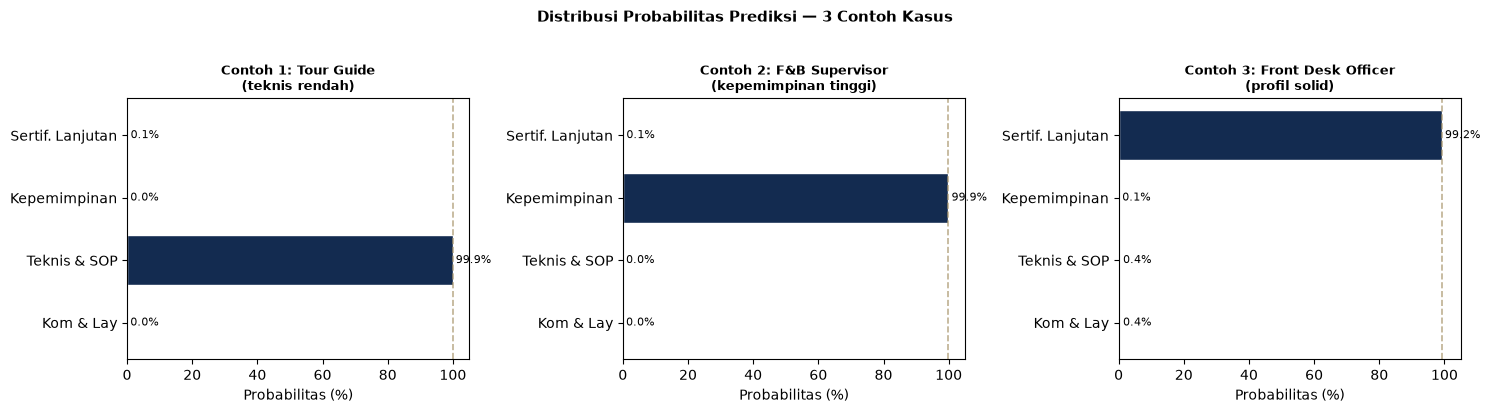

In [53]:
# ── Visualisasi confidence 3 contoh kasus
label_short  = ["Kom & Lay", "Teknis & SOP", "Kepemimpinan", "Sertif. Lanjutan"]
fig, axes    = plt.subplots(1, 3, figsize=(15, 4))
titles       = ["Contoh 1: Tour Guide\n(teknis rendah)",
                "Contoh 2: F&B Supervisor\n(kepemimpinan tinggi)",
                "Contoh 3: Front Desk Officer\n(profil solid)"]
contoh_list  = [contoh_1, contoh_2, contoh_3]

for ax, contoh, title in zip(axes, contoh_list, titles):
    probas = list(contoh["semua_proba"].values())
    bar_c  = ["#132B50" if i == contoh["label_id"] else "#d9cdb8"
              for i in range(4)]
    bars   = ax.barh(label_short, probas, color=bar_c, edgecolor="white")
    ax.set_xlim(0, 105)
    ax.set_xlabel("Probabilitas (%)")
    ax.set_title(title, fontweight="bold", fontsize=9)
    for bar, val in zip(bars, probas):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=8)
    pred_prob = probas[contoh["label_id"]]
    ax.axvline(pred_prob, color="#A49063", linestyle="--", linewidth=1.2, alpha=0.7)

plt.suptitle("Distribusi Probabilitas Prediksi — 3 Contoh Kasus",
             fontweight="bold", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("plot_inference_examples.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 8. Ringkasan & Rekomendasi untuk Implementasi Flask

### Hasil Evaluasi Model


In [54]:
# ── Tabel ringkasan final
print("=" * 70)
print("RINGKASAN PERFORMA MODEL — SDC Course Recommendation System")
print("=" * 70)
print(df_results.to_string(index=True))
print()
final_f1  = f1_score(y_test, y_pred_best_tuned, average='macro')
final_acc = accuracy_score(y_test, y_pred_best_tuned)

print(f"Model terpilih untuk produksi: {best_name_safe} (post-tuning)")
print(f"  Test Accuracy : {final_acc:.4f}")
print(f"  Test F1-macro : {final_f1:.4f}")
print()

# Narasi otomatis — tidak hardcode nama model
excluded = df_results[df_results["Suspect Overfit"] == "YA"]["Model"].tolist()
if excluded:
    print(f"Catatan pemilihan model:")
    print(f"  - Dikecualikan karena suspect overfit (F1≥1.0 atau gap >15%): {', '.join(excluded)}")
    print(f"  - {best_name_safe} dipilih sebagai model valid terbaik.")
    if final_f1 >= 0.999:
        print(f"   Perhatian: model terpilih juga menghasilkan F1={final_f1:.4f} setelah tuning.")
        print(f"     Ini mengindikasikan data dummy terlalu deterministik.")
        print(f"     Perlu validasi ulang dengan data nyata sebelum deploy produksi.")


RINGKASAN PERFORMA MODEL — SDC Course Recommendation System
                 Model  CV F1-macro (mean)  CV F1-macro (std)  Test Accuracy  Test F1-macro  CV-Test Gap Suspect Overfit
1    Gradient Boosting            0.800376           0.039152         0.8625       0.861310      -0.0609              OK
2        Random Forest            0.820408           0.024125         0.7750       0.780021       0.0404              OK
3        Decision Tree            0.765431           0.060699         0.7625       0.766612      -0.0012              OK
4  Logistic Regression            0.717605           0.025977         0.7500       0.752713      -0.0351              OK
5            SVM (RBF)            0.751332           0.043184         0.7125       0.716934       0.0344              OK
6          Extra Trees            0.730936           0.025602         0.6625       0.677180       0.0538              OK
7          Naive Bayes            0.656694           0.082397         0.6000       0.605811  

---
### Cara Integrasi ke Flask

```python
# app.py (snippet)
import pickle, pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load artifacts satu kali saat startup
with open("sdc_model.pkl", "rb") as f:
    artifacts = pickle.load(f)
df_course = pd.read_csv("data_course.csv")

@app.route("/api/rekomendasi", methods=["POST"])
def rekomendasi():
    data = request.json  # profil pegawai dari frontend
    result = predict_course_category(
        skill_dict         = data["skills"],
        pre_score          = data["pre_score"],
        post_score         = data["post_score"],
        kinerja_list       = data["kinerja"],
        divisi             = data["divisi"],
        status_sertifikat  = data["status_sertifikat"],
        model_artifacts    = artifacts,
        df_course          = df_course,
    )
    return jsonify(result)
```

### File yang dihasilkan notebook ini

| File | Keterangan |
|------|------------|
| `data_pegawai.csv` | Dataset training (400 pegawai) |
| `data_course.csv`  | Katalog course (24 course, 4 kategori) |
| `sdc_model.pkl`    | Model + preprocessor + metadata (siap deploy) |
| `plot_*.png`       | Semua visualisasi (7 file) |

### Catatan untuk pengembangan selanjutnya
1. **Label lebih granular** — label saat ini 4 kelas, bisa diperluas ke per-jabatan
2. **Multi-label** — satu pegawai bisa butuh lebih dari 1 kategori (sklearn MultiOutputClassifier)
3. **Data nyata** — ganti data dummy dengan data riil dari sistem SDC
4. **Retraining pipeline** — tambahkan MLflow atau minimal versioning model
5. **A/B testing** — bandingkan rekomendasi model vs rule-based di production
